<a href="https://colab.research.google.com/github/paninishah/deepdream/blob/main/deepdream2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
#toolkit for neural networks, computes gradients automatically (automatic differentiation)
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import inception_v3
from tensorflow.keras.preprocessing import image

In [2]:
# Load pretrained InceptionV3 without classification head

base_model = inception_v3.InceptionV3(
    weights='imagenet',
    include_top=False
)

base_model.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


select multiple laters instead of a single layer

In [3]:
# DeepDream works by maximizing activations
# from selected layers of the network.

layer_names = [
    "mixed3",
    "mixed5",
    "mixed7"
]

# Collect outputs from each layer

layer_outputs = [
    base_model.get_layer(name).output
    for name in layer_names
]

# Create model that returns activations
# from all selected layers

dream_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=layer_outputs
)

print("Layers used for dreaming:")
for name in layer_names:
    print("-", name)

Layers used for dreaming:
- mixed3
- mixed5
- mixed7


In [4]:
img_path = tf.keras.utils.get_file(
    "dream.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
)

print(img_path)

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
/root/.keras/datasets/dream.jpg


In [5]:
#preprocessing

# Load image

img = image.load_img(img_path)

# Convert to array

img = image.img_to_array(img)

# Add batch dimension

img = np.expand_dims(img, axis=0)

# InceptionV3 preprocessing

img = inception_v3.preprocess_input(img)

# Convert to tensor

img = tf.convert_to_tensor(img)

print(img.shape)

(1, 577, 700, 3)


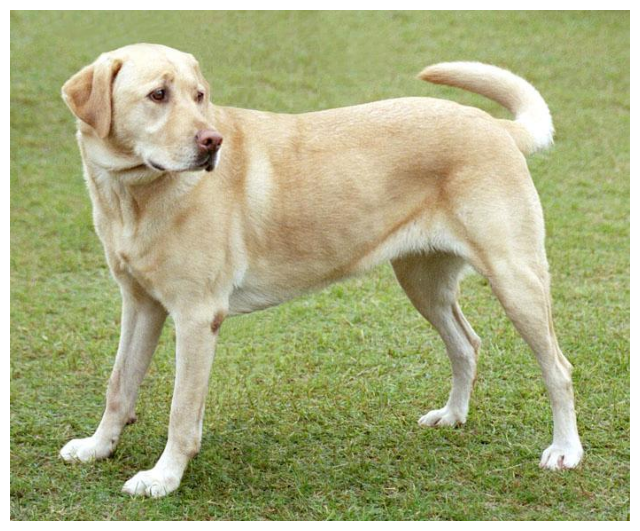

In [6]:
plt.figure(figsize=(8,8))

display_img = img[0].numpy()

display_img = (display_img + 1.0) / 2.0

plt.imshow(display_img)

plt.axis("off")
plt.show()

multi-layer loss function:

In [16]:
def calc_loss(img):

    activations = dream_model(img)

    loss = 0

    for activation in activations:
        loss += tf.reduce_mean(activation)

    return loss

In [17]:
@tf.function
def dream_step(img, learning_rate):

    with tf.GradientTape() as tape:

        tape.watch(img)

        loss = calc_loss(img)

    gradients = tape.gradient(loss, img)

    # IMPORTANT: this existed in DeepDream1
    gradients /= tf.math.reduce_std(gradients) + 1e-8

    img = img + learning_rate * gradients

    return loss, img

In [18]:
steps = 100
learning_rate = 0.01

dream_img = tf.identity(img)

for step in range(steps):

    loss, dream_img = dream_step(
        dream_img,
        learning_rate
    )

    if step % 10 == 0:

        print(
            f"Step {step}: "
            f"Loss = {loss.numpy():.4f}"
        )

Step 0: Loss = 0.5929
Step 10: Loss = 1.1946
Step 20: Loss = 1.4571
Step 30: Loss = 1.6199
Step 40: Loss = 1.7442
Step 50: Loss = 1.8520
Step 60: Loss = 1.9438
Step 70: Loss = 2.0241
Step 80: Loss = 2.0967
Step 90: Loss = 2.1640


In [19]:
result = dream_img[0].numpy()

result = (result + 1.0) / 2.0

result = np.clip(result, 0, 1)

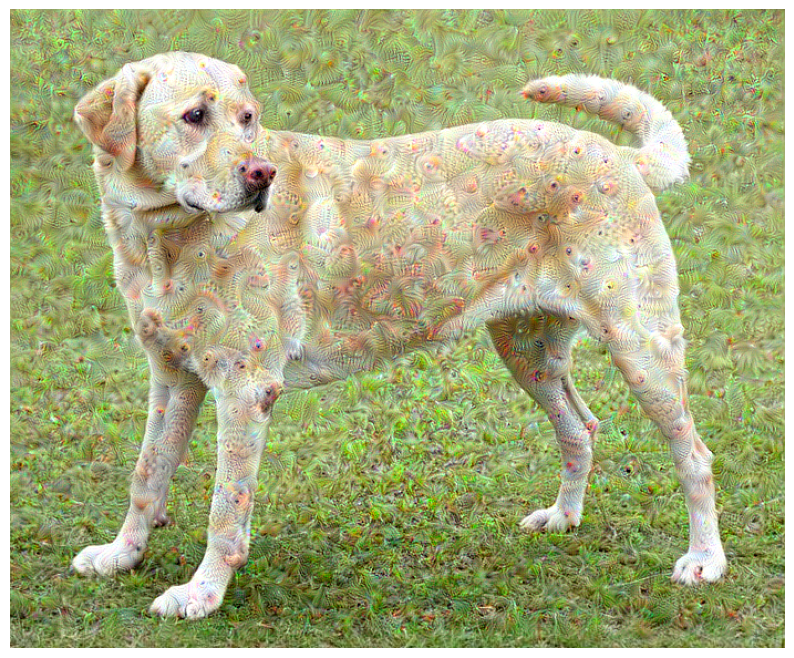

In [20]:
plt.figure(figsize=(10,10))

plt.imshow(result)

plt.axis("off")

plt.show()